# Statistical Significance & p-Values

> **Goal:** Determine whether an observed result is **too extreme to be explained by random chance alone**.

---

## 📊 Visual Intuition

![P-value on Normal Distribution](https://upload.wikimedia.org/wikipedia/commons/thumb/3/37/Comparison_of_one-tailed_and_two-tailed_p-values.svg/800px-Comparison_of_one-tailed_and_two-tailed_p-values.svg.png)

The shaded tail represents the **p-value** — the probability of obtaining a result **at least as extreme** as the observed one, **assuming the Null Hypothesis (H₀) is true**.

---

## Statistical Significance

A result is **statistically significant** if it is **unlikely to occur by random chance** under the Null Hypothesis.

---

## p-value

### Definition

The **p-value** is:

> **The probability of observing a result as extreme as (or more extreme than) the observed result, assuming the Null Hypothesis (H₀) is true.**

### Formula (Permutation Test)

```python
p_value = count_of_extreme_results / total_permutations
```

Example:

```text
8 extreme results out of 10,000 permutations

p = 8 / 10000 = 0.0008
```

Interpretation:

> If H₀ is true, a result this extreme would occur only **0.08%** of the time.

---

## Important

❌ **Incorrect**

> "The p-value is the probability that H₀ is true."

✅ **Correct**

> "The p-value is the probability of obtaining data this extreme (or more extreme), **assuming H₀ is true**."

---

## Alpha (α)

Alpha is the **predefined significance threshold**.

Common choices:

- **0.05 (5%)**
- **0.01 (1%)**

Decision Rule:

```text
If p ≤ α
    Reject H₀
Else
    Fail to Reject H₀
```

---

## Example

| p-value | α | Decision |
|---------:|:--:|----------|
| 0.001 | 0.05 | Reject H₀ ✅ |
| 0.030 | 0.05 | Reject H₀ ✅ |
| 0.308 | 0.05 | Fail to Reject H₀ ❌ |

---

## Statistical vs Practical Significance

### Statistical Significance
- Result is unlikely due to chance.

### Practical Significance
- Result is **large enough to matter** in the real world.

A tiny improvement can be statistically significant with a huge sample size but still have little business value.

---

## Type I Error (False Positive)

Reality:

```text
No Effect
```

Decision:

```text
Reject H₀
```

➡️ Concluding an effect exists when it actually doesn't.

---

## Type II Error (False Negative)

Reality:

```text
Real Effect Exists
```

Decision:

```text
Fail to Reject H₀
```

➡️ Missing a real effect.

---

## Data Science Perspective

A p-value is **one piece of evidence**, not the final decision.

Also consider:

- Effect Size
- Confidence Interval
- Business Impact
- Cost of Wrong Decisions
- Domain Knowledge

---

## Common Misconceptions

❌ p-value = Probability H₀ is true.

❌ Small p-value = Huge effect.

❌ Statistical significance = Practical importance.

---

## Key Takeaways

- Statistical significance tests whether an observed result is unusual under H₀.
- A p-value measures how compatible the observed data is with the Null Hypothesis.
- Alpha (α) is the threshold used to decide statistical significance.
- Rejecting H₀ does **not** prove H₁.
- Statistical significance does **not** imply practical significance.
- Always interpret p-values alongside effect size and business context.

---

## 🎯 Interview Tip

**Q:** What does a p-value of 0.03 mean?

**Correct Answer:**

> Assuming the Null Hypothesis is true, there is a **3% probability of observing a result at least as extreme as the one obtained**.

**Not:**

> There is a 3% probability that the Null Hypothesis is true.

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import pandas as pd 

np.random.seed(42)

In [2]:
page_a = np.array([12, 15, 18, 20, 22])
page_b = np.array([13,12,21,20,25])

In [3]:
diff = page_b.mean() - page_a.mean()
print(diff)

0.8000000000000007


In [4]:
combined = np.concatenate([page_a, page_b])
print(combined)

[12 15 18 20 22 13 12 21 20 25]


In [5]:
np.random.shuffle(combined) # shuffle in place
print(combined)

[20 15 13 12 21 18 25 22 20 12]


In [6]:
r_means = []
for _ in range(1000):
    np.random.shuffle(combined)
    a = combined[:5]
    b = combined[5:]
    r_means.append(b.mean() - a.mean())

print(r_means[:10])

[np.float64(1.6000000000000014), np.float64(-4.4), np.float64(1.6000000000000014), np.float64(3.1999999999999993), np.float64(-4.0), np.float64(0.3999999999999986), np.float64(2.3999999999999986), np.float64(0.8000000000000007), np.float64(3.6000000000000014), np.float64(3.1999999999999993)]


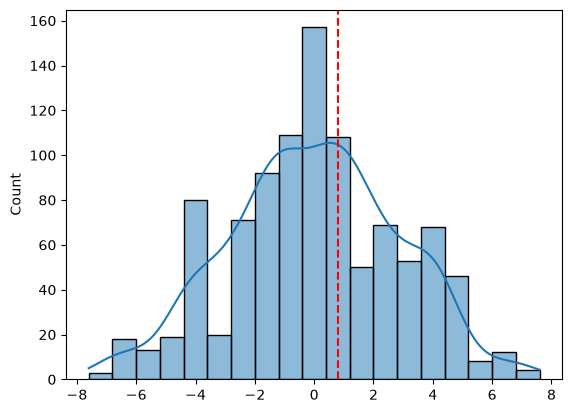

In [7]:
sns.histplot(
    data = r_means,
    bins = "auto",
    kde = True
)
plt.axvline(diff, linestyle = "--", color = "red")
plt.show()

In [8]:
p_value = np.sum(r_means >= diff) / 1000
print(p_value)

0.418


In [9]:
a = 0.05

if(p_value <= a):
    print("Reject H0")
else:
    print("Fail to reject H0")

Fail to reject H0
